# **NLP Feature Engineering Part 2: Model-Based Semantic Signals**

**Project**: Airbnb Market Segmentation Analysis
**Goal**: Extend the candidate feature set built in Part 1 with model-based semantic signals (sentiment, topic modeling, and multilingual embeddings) to test whether text captures structure beyond surface-level stylometry and lexicons, using a shared, capped review sample to keep the heavier phases computationally feasible.

## 1. Imports & environment setup

In [1]:
import pandas as pd
import numpy as np
import re
import html

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
# Base path configuration
BASE_PATH = Path.cwd().parent

In [12]:
import torch

DEVICE = 'mps' # torch.backends.mps.is_available()

## 2. Data Loading

In [3]:
listings_nlp = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'listings_extended.csv')
reviews_nlp = pd.read_csv(BASE_PATH / 'data' / 'processed' / 'reviews_extended.csv')

#### 2.1 Listings dataframe

In [4]:
listings_nlp.shape

(35818, 282)

In [5]:
listings_nlp.info()

<class 'pandas.DataFrame'>
RangeIndex: 35818 entries, 0 to 35817
Columns: 282 entries, id to review_transport_density_log
dtypes: float64(170), int64(38), str(74)
memory usage: 77.1 MB


In [6]:
listings_nlp.describe(include = 'all')

,id,host_id,host_response_time,host_response_rate_raw,host_acceptance_rate_raw,host_is_superhost,host_neighbourhood,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,...,review_luxury_density_log,review_family_density_log,review_budget_density_log,review_romantic_density_log,review_authenticity_density_log,review_atmosphere_quiet_density_log,review_atmosphere_lively_density_log,description_transport_density_log,neighborhood_overview_transport_density_log,review_transport_density_log
count,3.581800e+04,3.581800e+04,35818,29444.000000,32319.000000,35818.000000,35818,35818.000000,35818.000000,35818,...,30286.000000,30286.000000,30286.000000,30286.000000,30286.000000,30286.000000,30286.000000,34854.000000,16442.000000,30286.000000
unique,NaN,NaN,5,NaN,NaN,NaN,100,NaN,NaN,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,within an hour,NaN,NaN,NaN,Unknown,NaN,NaN,I Centro Storico,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,25098,NaN,NaN,NaN,24751,NaN,NaN,17537,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.541191e+17,2.666308e+08,NaN,0.966612,0.926700,0.399213,NaN,0.939835,0.919063,NaN,...,0.079051,0.104405,0.338749,0.044385,0.350897,0.246099,0.393843,0.447744,0.388195,0.318760
std,5.746268e+17,2.439774e+08,NaN,0.136872,0.201959,0.489743,NaN,0.237796,0.272742,NaN,...,0.155806,0.179290,0.292853,0.098787,0.271740,0.270789,0.297838,0.577434,0.573619,0.273992
min,1.183400e+04,2.353000e+03,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.020579e+07,3.129867e+07,NaN,1.000000,0.980000,0.000000,NaN,1.000000,1.000000,NaN,...,0.000000,0.000000,0.147337,0.000000,0.184240,0.000000,0.194892,0.000000,0.000000,0.115317
50%,9.565242e+17,1.901475e+08,NaN,1.000000,1.000000,0.000000,NaN,1.000000,1.000000,NaN,...,0.020688,0.011195,0.316052,0.000000,0.343037,0.185378,0.375588,0.000000,0.000000,0.293329
75%,1.271719e+18,5.070057e+08,NaN,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,NaN,...,0.096779,0.151850,0.460776,0.057309,0.473627,0.363167,0.552444,0.870875,0.790728,0.460790


#### 2.2 Reviews dataframe

In [7]:
reviews_nlp.shape

(2193159, 7)

In [8]:
reviews_nlp.info()

<class 'pandas.DataFrame'>
RangeIndex: 2193159 entries, 0 to 2193158
Data columns (total 7 columns):
 #   Column                 Dtype
---  ------                 -----
 0   listing_id             int64
 1   date                   str  
 2   reviewer_id            int64
 3   comments_clean         str  
 4   review_length          int64
 5   is_substantive_review  int64
 6   review_lang            str  
dtypes: int64(4), str(3)
memory usage: 117.1 MB


In [9]:
reviews_nlp.describe(include = 'all')

,listing_id,date,reviewer_id,comments_clean,review_length,is_substantive_review,review_lang
count,2.193159e+06,2193159,2.193159e+06,2193122,2.193159e+06,2.193159e+06,2193159
unique,NaN,5242,NaN,2123477,NaN,NaN,71
top,NaN,2025-06-15,NaN,unknown,NaN,NaN,en
freq,NaN,3059,NaN,4095,NaN,NaN,1284508
mean,2.786878e+17,NaN,1.988891e+08,NaN,2.691344e+02,9.981328e-01,NaN
std,4.496488e+17,NaN,1.838524e+08,NaN,2.415276e+02,4.317041e-02,NaN
min,2.737000e+03,NaN,4.600000e+01,NaN,0.000000e+00,0.000000e+00,NaN
25%,9.950970e+06,NaN,4.574545e+07,NaN,1.030000e+02,1.000000e+00,NaN
50%,2.920817e+07,NaN,1.344770e+08,NaN,2.050000e+02,1.000000e+00,NaN
75%,6.590309e+17,NaN,3.235598e+08,NaN,3.600000e+02,1.000000e+00,NaN


## 3. Shared Review Sample

Reviews are capped at 30 per listing via random sampling with a fixed seed, not by recency or quality, to stay representative of a listing's review history. Listings with 30 or fewer substantive reviews keep all of them. This single `reviews_sampled` dataframe is built once here and reused unchanged across sentiment, topic modeling, and embeddings, so a listing's scores across all three phases come from the same underlying text, not three independently drawn samples.

In [14]:
REVIEW_CAP = 30
RANDOM_SEED = 42

substantive_mask = reviews_nlp['is_substantive_review'] == 1
substantive_reviews = reviews_nlp.loc[substantive_mask].copy()

reviews_sampled = (
    substantive_reviews
    .sample(frac=1, random_state=RANDOM_SEED)  # shuffle the whole frame once, reproducibly
    .groupby('listing_id', group_keys=False)
    .head(REVIEW_CAP)  # first N after a full shuffle == a random sample of up to N per group
    .reset_index(drop=True)
)

print(f"substantive reviews (full corpus): {len(substantive_reviews):,}")
print(f"reviews_sampled (capped at {REVIEW_CAP}): {len(reviews_sampled):,} "
      f"({len(reviews_sampled)/len(substantive_reviews)*100:.1f}% of substantive corpus)")
print(f"listings covered: {reviews_sampled['listing_id'].nunique():,}")

reviews_per_listing_capped = reviews_sampled.groupby('listing_id').size()
print(f"\nreviews per listing after capping — min: {reviews_per_listing_capped.min()}, "
      f"median: {reviews_per_listing_capped.median()}, max: {reviews_per_listing_capped.max()}")

substantive reviews (full corpus): 2,189,064
reviews_sampled (capped at 30): 631,263 (28.8% of substantive corpus)
listings covered: 32,250

reviews per listing after capping — min: 1, median: 27.0, max: 30


## 4. Sentiment Analysis

Numeric review scores (`review_scores_*`) suffer from a ceiling effect, leaving almost no separation between listings on this axis. Review text is the only remaining source of graded variation. This section extracts a continuous sentiment signal from `reviews_sampled` via `nlptown/bert-base-multilingual-uncased-sentiment`, chosen over translation-dependent alternatives for its closer register match (product/service reviews) and native coverage of the project's main languages. Per-review star predictions are aggregated to listing level (mean/std/%negative/trend), followed by a corpus-bootstrapped complaint lexicon and lightweight aspect-anchored sentiment.

### 4.1 Language Coverage Check

Before running inference on the full sample, actual language coverage on `reviews_sampled` is checked directly, rather than assumed from the model's documentation. `nlptown` covers English, Dutch, German, French, Spanish, Italian; anything else falls outside its trained coverage and will be marked `unavailable`.

In [15]:
NLPTOWN_LANGS = {'en', 'nl', 'de', 'fr', 'es', 'it'}

lang_counts = reviews_sampled['review_lang'].value_counts()
lang_pct = reviews_sampled['review_lang'].value_counts(normalize=True).mul(100).round(2)

lang_coverage = pd.DataFrame({'count': lang_counts, 'pct': lang_pct})
lang_coverage['covered_by_nlptown'] = lang_coverage.index.isin(NLPTOWN_LANGS)

display(lang_coverage.head(20))

covered_pct = lang_coverage.loc[lang_coverage['covered_by_nlptown'], 'pct'].sum()
print(f"\nTotal coverage by nlptown model: {covered_pct:.1f}% of reviews_sampled")
print(f"Falls outside coverage (incl. Russian, too_short, unknown): {100 - covered_pct:.1f}%")

,count,pct,covered_by_nlptown
review_lang,,,
en,331543,52.52,True
it,72074,11.42,True
es,58416,9.25,True
fr,56623,8.97,True
too_short,42161,6.68,False
de,22484,3.56,True
pt,12534,1.99,False
nl,5295,0.84,True
ko,4792,0.76,False



Total coverage by nlptown model: 86.6% of reviews_sampled
Falls outside coverage (incl. Russian, too_short, unknown): 13.4%


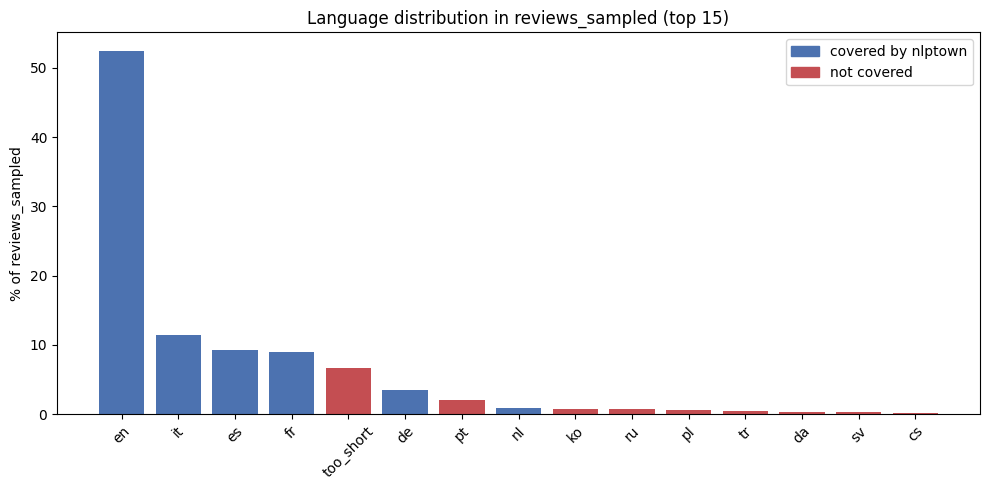

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
top15 = lang_coverage.head(15)
colors_lang = ['#4c72b0' if covered else '#c44e52' for covered in top15['covered_by_nlptown']]
ax.bar(top15.index, top15['pct'], color=colors_lang)
ax.set_ylabel('% of reviews_sampled')
ax.set_title('Language distribution in reviews_sampled (top 15)')
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4c72b0', label='covered by nlptown'),
                    Patch(color='#c44e52', label='not covered')])
plt.tight_layout()
plt.show()

**Observations:**

86.6% coverage confirms `nlptown` is a solid choice without needing a second model. The single largest "not covered" bucket isn't a missing language at all: `too_short` (6.68%) reflects the same detection-reliability limit already documented throughout this project (texts under 5 words), not a gap in the sentiment model's training. Among genuine language gaps, Portuguese is the largest at just 1.99%, followed by Russian at 0.72% (4,556 reviews), both too small to justify adding a second model with an incompatible output scale just to cover them. All languages outside `nlptown`'s six are marked `unavailable`, consistent with every other language-limited method in this project.